In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [45]:

df = pd.read_csv("car_prices.csv")
print("Datos cargados:")
print(f"Shape: {df.shape}")
print(df.head())

Datos cargados:
Shape: (558837, 16)
   year   make                model        trim   body transmission  \
0  2015    Kia              Sorento          LX    SUV    automatic   
1  2015    Kia              Sorento          LX    SUV    automatic   
2  2014    BMW             3 Series  328i SULEV  Sedan    automatic   
3  2015  Volvo                  S60          T5  Sedan    automatic   
4  2014    BMW  6 Series Gran Coupe        650i  Sedan    automatic   

                 vin state  condition  odometer  color interior  \
0  5xyktca69fg566472    ca        5.0   16639.0  white    black   
1  5xyktca69fg561319    ca        5.0    9393.0  white    beige   
2  wba3c1c51ek116351    ca       45.0    1331.0   gray    black   
3  yv1612tb4f1310987    ca       41.0   14282.0  white    black   
4  wba6b2c57ed129731    ca       43.0    2641.0   gray    black   

                                   seller      mmr  sellingprice  \
0                 kia motors america  inc  20500.0       21500.0  

In [46]:
print("Información del dataset:")
print(df.info())

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  str    
 2   model         548438 non-null  str    
 3   trim          548186 non-null  str    
 4   body          545642 non-null  str    
 5   transmission  493485 non-null  str    
 6   vin           558833 non-null  str    
 7   state         558837 non-null  str    
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  str    
 11  interior      558088 non-null  str    
 12  seller        558837 non-null  str    
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 68.2 MB
None


In [47]:
print("Descripción:")
print(df.describe())

Descripción:
                year      condition       odometer            mmr  \
count  558837.000000  547017.000000  558743.000000  558799.000000   
mean     2010.038927      30.672365   68320.017767   13769.377495   
std         3.966864      13.402832   53398.542821    9679.967174   
min      1982.000000       1.000000       1.000000      25.000000   
25%      2007.000000      23.000000   28371.000000    7100.000000   
50%      2012.000000      35.000000   52254.000000   12250.000000   
75%      2013.000000      42.000000   99109.000000   18300.000000   
max      2015.000000      49.000000  999999.000000  182000.000000   

        sellingprice  
count  558825.000000  
mean    13611.358810  
std      9749.501628  
min         1.000000  
25%      6900.000000  
50%     12100.000000  
75%     18200.000000  
max    230000.000000  


In [48]:

print("Valores nulos:")
print(df.isnull().sum())

Valores nulos:
year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64


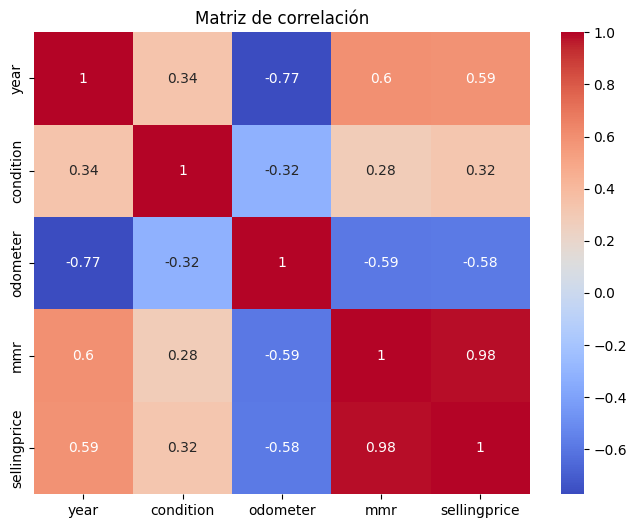

In [49]:

corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

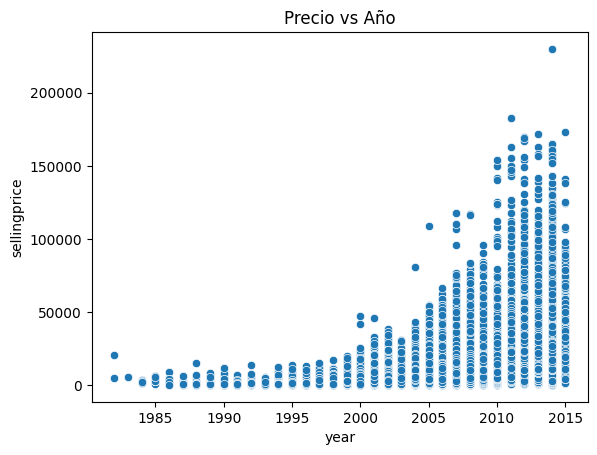

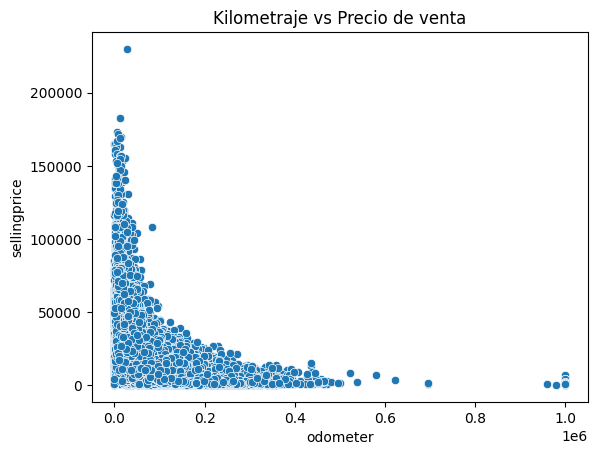

In [50]:
sns.scatterplot(x="year", y="sellingprice", data=df)
plt.title("Precio vs Año")
plt.show()

sns.scatterplot(x="odometer", y="sellingprice", data=df)
plt.title("Kilometraje vs Precio de venta")
plt.show()


# Regresion Lineal Multiple

In [59]:

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


df_limpio = df[['mmr', 'odometer', 'sellingprice']].dropna()
print(f"Datos originales: {len(df)} filas")
print(f"Datos después de limpiar nulos: {len(df_limpio)} filas")

X = df_limpio[['mmr', 'odometer']]  # Variables independientes
y = df_limpio['sellingprice']  # Variable dependiente

print("\nVariables definidas:")
print(f"- Variables independientes: {X.columns.tolist()}")
print(f"- Variable dependiente: sellingprice")
print(f"- Forma de X: {X.shape}")
print(f"- Forma de y: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nDivisión de datos:")
print(f"- Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"- Conjunta de prueba: {X_test.shape[0]} muestras")

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("\nModelo de Regresión Lineal Múltiple entrenado")
print(f"- Intercepto: {modelo.intercept_:.4f}")
print(f"- Coeficientes: {dict(zip(X.columns, modelo.coef_))}")

y_pred = modelo.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nEvaluación del modelo:")
print(f"- R² (Coeficiente de determinación): {r2:.4f}")
print(f"- Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"- Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")

print("\nEjemplo de predicciones:")
for i in range(5):
    print(f"Muestra {i+1}:")
    print(f"  - Variables: mmr={X_test.iloc[i]['mmr']}, odometer={X_test.iloc[i]['odometer']}")
    print(f"  - Valor real: {y_test.iloc[i]:.2f}")
    print(f"  - Predicción: {y_pred[i]:.2f}")
    print()

print(f"El modelo de regresión lineal múltiple explica aproximadamente el {r2*100:.2f}% de la variabilidad")
print("en los precios de venta de los vehículos utilizando las variables independientes:")
print("- mmr (precio de mercado recomendado)")
print("- odometer (kilometraje)")
print()
print(f"El error promedio en las predicciones es de aproximadamente ${rmse:.2f}.")
print()
print("Variables explicativas:")
print(f"  - mmr: {modelo.coef_[0]:.4f}")
print(f"  - odometer: {modelo.coef_[1]:.4f}")
print()

resultados = pd.DataFrame({
    'Real': y_test.values,
    'Predicho': y_pred
})

print(resultados.head())

mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse}")

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

r2 = r2_score(y_test, y_pred)
print("R2:", r2)

efectividad = 'es efectivo' if r2 > 0.7 else 'tiene un rendimiento moderado'

print("Conclusión: El modelo de regresión lineal múltiple " + efectividad + " para predecir precios de vehículos.")


Datos originales: 558837 filas
Datos después de limpiar nulos: 558705 filas

Variables definidas:
- Variables independientes: ['mmr', 'odometer']
- Variable dependiente: sellingprice
- Forma de X: (558705, 2)
- Forma de y: (558705,)

División de datos:
- Conjunto de entrenamiento: 446964 muestras
- Conjunta de prueba: 111741 muestras

Modelo de Regresión Lineal Múltiple entrenado
- Intercepto: 99.0553
- Coeficientes: {'mmr': np.float64(0.9869269860118175), 'odometer': np.float64(-0.0011236132174798955)}

Evaluación del modelo:
- R² (Coeficiente de determinación): 0.9686
- Error Cuadrático Medio (MSE): 2995581.3580
- Raíz del Error Cuadrático Medio (RMSE): 1730.7748

Ejemplo de predicciones:
Muestra 1:
  - Variables: mmr=12450.0, odometer=38456.0
  - Valor real: 11200.00
  - Predicción: 12343.09

Muestra 2:
  - Variables: mmr=18900.0, odometer=63877.0
  - Valor real: 16900.00
  - Predicción: 18680.20

Muestra 3:
  - Variables: mmr=12800.0, odometer=96525.0
  - Valor real: 13600.00
  - P

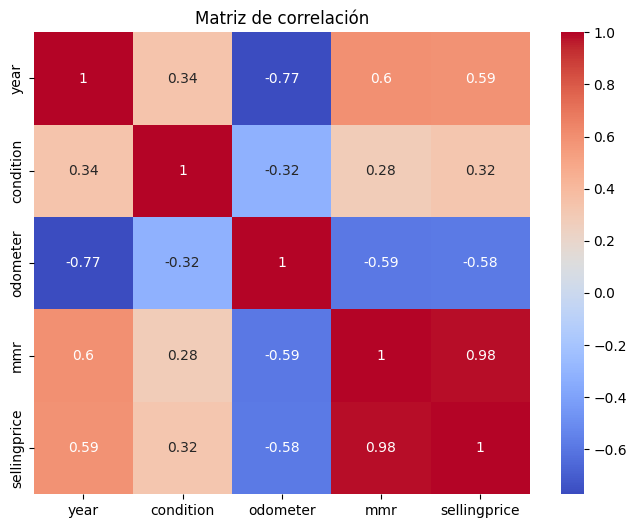

In [ ]:

corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

# Regresion logistica


Regresión logistica - Titanic
Datos del Titanic cargados:
Shape: (1309, 14)
   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

      age  sibsp  parch  ticket      fare    cabin embarked boat body  \
0      29      0      0   24160  211.3375       B5        S    2    ?   
1  0.9167      1      2  113781    151.55  C22 C26        S   11    ?   
2       2      1      2  113781    151.55  C22 C26        S    ?    ?   
3      30      1      2  113781    151.55  C22 C26        S    ?  135   
4      25      1      2  113781    151.55  C22 C26        S    ?    ?   

    

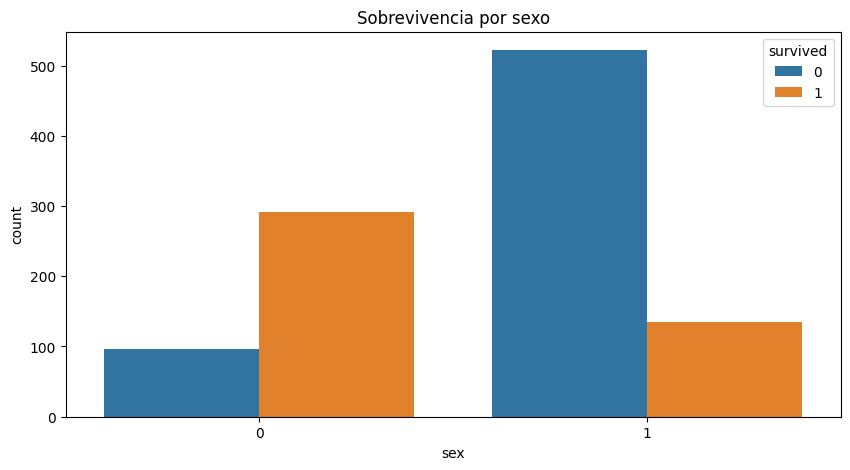

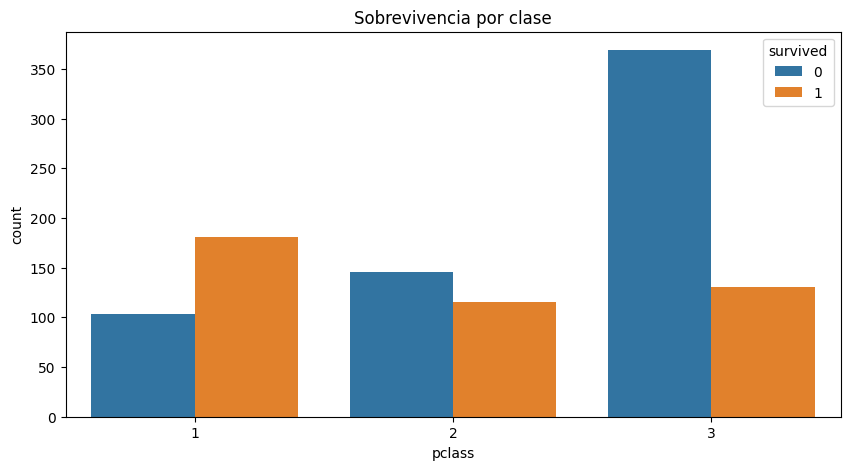

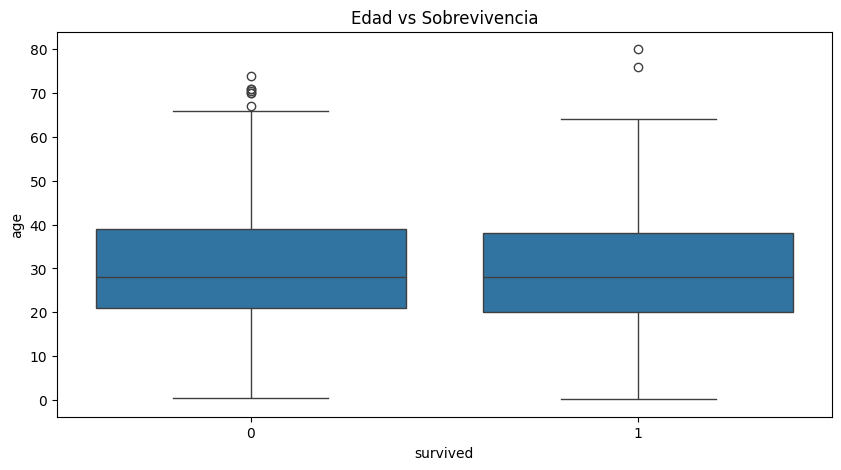

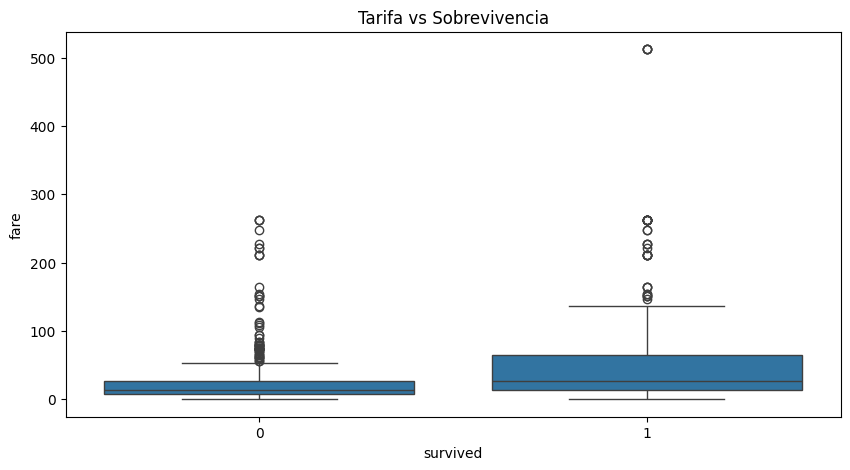

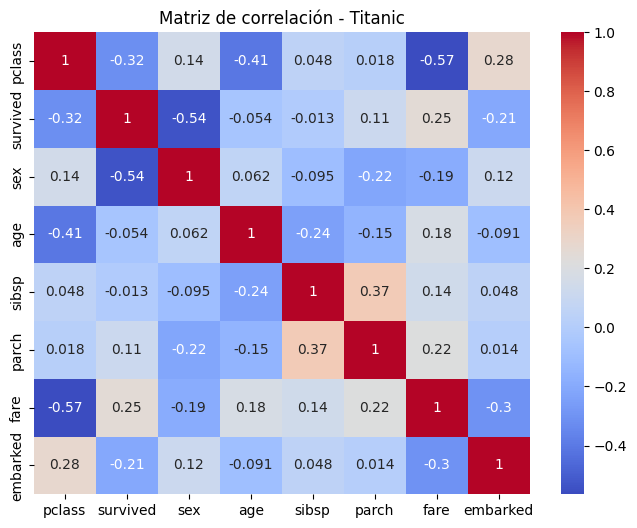


Prueba t-test: Edad vs Sobrevivencia
Media de edad de sobrevivientes: 28.92
Media de edad de no sobrevividos: 30.50
Estadístico t: -1.7451
Valor p: 0.0813

La diferencia NO es estadísticamente significativa (p >= 0.05)

Variables definidas para regresión logística:
- Variables independientes: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
- Variable dependiente: survived
- Forma de X: (1045, 7)
- Forma de y: (1045,)

División de datos - Titanic:
- Conjunto de entrenamiento: 836 muestras
- Conjunto de prueba: 209 muestras
Modelo de Regresión Logística
- Intercepto: 5.0292
- Coeficientes:
    pclass: -1.0319
    sex: -2.6258
    age: -0.0385
    sibsp: -0.3410
    parch: 0.0501
    fare: 0.0016
    embarked: -0.1404
MSE: 2995581.3580282
concluson: El modelo de regresión logística muestra cómo cada variable independiente afecta la probabilidad de supervivencia en el Titanic.
------------------------------------------------------------------------


In [ ]:

print("Regresión logistica - Titanic")

from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df2 = pd.read_csv("titanic.csv")
print("Datos del Titanic cargados:")
print(f"Shape: {df2.shape}")
print(df2.head())

print("Información del dataset:")
print(df2.info())
print("Columnas disponibles:", df2.columns.tolist())
print()

columnas_eliminar = ['name', 'ticket', 'cabin', 'boat', 'body', 'home.dest']
df2_limpio = df2.drop(columns=columnas_eliminar)
print("Columnas eliminadas:", columnas_eliminar)
print()

print("Valores nulos antes de limpiar:")
print(df2_limpio.isnull().sum())
print()

df2_limpio = df2_limpio.dropna()
print(f"Datos después de limpiar nulos: {len(df2_limpio)} filas")
print()
print("Tipos de datos:")
print(df2_limpio.dtypes)

df2_limpio['sex'] = df2_limpio['sex'].astype('category')
df2_limpio['embarked'] = df2_limpio['embarked'].astype('category')

df2_limpio['age'] = pd.to_numeric(df2_limpio['age'], errors='coerce')
df2_limpio['fare'] = pd.to_numeric(df2_limpio['fare'], errors='coerce')

df2_limpio = df2_limpio.dropna()

df2_limpio['sex'] = df2_limpio['sex'].cat.codes
df2_limpio['embarked'] = df2_limpio['embarked'].cat.codes

print("\nDatos después de conversión:")
print(df2_limpio.dtypes)
print()
print(df2_limpio.head())

plt.figure(figsize=(10, 5))
sns.countplot(x='sex', hue='survived', data=df2_limpio)
plt.title('Sobrevivencia por sexo')
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(x='pclass', hue='survived', data=df2_limpio)
plt.title('Sobrevivencia por clase')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='survived', y='age', data=df2_limpio)
plt.title('Edad vs Sobrevivencia')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='survived', y='fare', data=df2_limpio)
plt.title('Tarifa vs Sobrevivencia')
plt.show()

corr2 = df2_limpio.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr2, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación - Titanic")
plt.show()

sobrevividos = df2_limpio[df2_limpio['survived'] == 1]['age']
no_sobrevividos = df2_limpio[df2_limpio['survived'] == 0]['age']

t_stat, p_value = stats.ttest_ind(sobrevividos, no_sobrevividos)

print("\nPrueba t-test: Edad vs Sobrevivencia")
print(f"Media de edad de sobrevivientes: {sobrevividos.mean():.2f}")
print(f"Media de edad de no sobrevividos: {no_sobrevividos.mean():.2f}")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")
print()
if p_value < 0.05:
    print("La diferencia ES estadísticamente significativa (p < 0.05)")
else:
    print("La diferencia NO es estadísticamente significativa (p >= 0.05)")

X2 = df2_limpio[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
y2 = df2_limpio['survived']

print("\nVariables definidas para regresión logística:")
print(f"- Variables independientes: {X2.columns.tolist()}")
print(f"- Variable dependiente: survived")
print(f"- Forma de X: {X2.shape}")
print(f"- Forma de y: {y2.shape}")

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

print("\nDivisión de datos - Titanic:")
print(f"- Conjunto de entrenamiento: {X2_train.shape[0]} muestras")
print(f"- Conjunto de prueba: {X2_test.shape[0]} muestras")

modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X2_train, y2_train)

print("Modelo de Regresión Logística")
print(f"- Intercepto: {modelo_log.intercept_[0]:.4f}")
print(f"- Coeficientes:")
for nombre, coef in zip(X2.columns, modelo_log.coef_[0]):
    print(f"    {nombre}: {coef:.4f}")

    


print("concluson: El modelo de regresión logística muestra cómo cada variable independiente afecta la probabilidad de supervivencia en el Titanic.")
print("------------------------------------------------------------------------")

# Ejercicios


Ejercicio 3

In [8]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.DataFrame({
    'horas_estudio': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'calificacion': [35, 45, 50, 55, 65, 70, 75, 85, 90, 95]
})

print("Correlación:", df['horas_estudio'].corr(df['calificacion']))

r, p_value = stats.pearsonr(df['horas_estudio'], df['calificacion'])
print("p-value:", p_value)

print("Covarianza:", df.cov())

Correlación: 0.9973831730843661
p-value: 2.0450956596553546e-10
Covarianza:                horas_estudio  calificacion
horas_estudio       9.166667     60.833333
calificacion       60.833333    405.833333


Ejercicio 7

In [ ]:

import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = np.array([2, 4, 5, 4, 5, 6, 7, 8, 9, 11])

modelo = LinearRegression()
modelo.fit(X, y)

print(f"Intercepto: {modelo.intercept_}") 
print(f"Pendiente: {modelo.coef_[0]}")   

prediccion = modelo.predict([[11]])
print(f"Predicción para X=11: {prediccion}")  

Intercepto: 1.4000000000000004
Pendiente: 0.8545454545454545
Predicción para X=11: [10.8]


Ejercicio 8


In [ ]:

from sklearn.metrics import r2_score

y_real = [1, 2, 3, 4, 5]
y_predicho = [1.1, 2.2, 2.9, 4.1, 4.9]

SS_res = sum((y - pred)**2 for y, pred in zip(y_real, y_predicho))
SS_tot = sum((y - sum(y_real)/len(y_real))**2 for y in y_real)

r2 = 1 - (SS_res / SS_tot)
print(f"R²: {r2}")

print(f"R² sklearn: {r2_score(y_real, y_predicho)}") # R²: 0.99

R²: 0.992
R² sklearn: 0.992


Ejercicio 9

In [5]:

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_real = [10, 20, 30, 40, 50]
y_predicho = [12, 18, 32, 38, 52]

rmse = np.sqrt(mean_squared_error(y_real, y_predicho))
mae = mean_absolute_error(y_real, y_predicho)

print(f"RMSE: {rmse}")  # Error promedio 
print(f"MAE: {mae}")   # Error absoluto medio

RMSE: 2.0
MAE: 2.0


Ejercicio 10

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_real = np.array([2.1, 4.2, 5.8, 4.3, 5.5, 6.8, 7.5, 8.2, 9.1, 10.5])
y_predicho = [2.3, 4.1, 5.9, 4.2, 5.6, 6.5, 7.4, 8.3, 9.0, 10.4]

residuos = np.array(y_real) - np.array(y_predicho)

print("Residuos:", residuos)
print("Media de residuos:", np.mean(residuos))  # ≈ 0.02

Residuos: [-0.2  0.1 -0.1  0.1 -0.1  0.3  0.1 -0.1  0.1  0.1]
Media de residuos: 0.02999999999999976


Ejercicio 12

In [7]:

from scipy import stats

x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y = [2, 4, 5, 4, 5, 6, 7, 8, 9, 11]

r, p_value = stats.pearsonr(x, y)

print(f"r: {r}")
print(f"p-value: {p_value}")

if p_value < 0.05:
    print("Rechazar H0: La correlación es significativa")
else:
    print("No rechazar H0: La correlación no es significativa")

r: 0.9634735449854439
p-value: 7.451501383552617e-06
Rechazar H0: La correlación es significativa
